# MRAC

Model Reference Adaptive Control (MRAC) is used when the true system is not known exactly due to noises, hiddens characteristics or evironment uncertenties.
![Screenshot From 2026-01-05 16-13-09.png](<attachment:Screenshot From 2026-01-05 16-13-09.png>)

So the goal is to fit another model to the current system with the help of some extra blocs. $Kx$ for the inputs, $Kr$ for the goal and $\phi$ for the noise in the perturbance to the inputs.
 - reference model
    $$\dot x_m(t) = A_m * x_m(t) + B_m * r(t)$$
 - plant model
    $$\dot x(t) = A * x(t) + B * r(t) + f(x)$$
 - disturbance model
    $$u_{ad} = W^T \phi(x)$$
 - control
    $$u = K_x*x + K_r*r - u_{ad}$$

Update of the parameters
$$\dot K_x = \gamma_x * x(t) * e(t) * PB$$
$$\dot K_r = \gamma_r * r(t) * e(t) * PB$$
$$\dot w = \gamma_w * \phi(t) * e(t) * PB$$

P is the solution to the following Lyapunov function based on the reference model state matrix and B is the control effective matrix from the plant model.

$$A^T_m P + P A_m + Q = 0$$

where $Q$ is a positive definite square matrix of size of the state.

The implementaton:
 1. get true state $x$ at instance $t$
 2. simulate reference model to get $x_m$
 3. calculate error $e = x - x_m$
 4. update gains
 5. compute the control signal $u = k_x x + k_r r$
 6. apply to the system
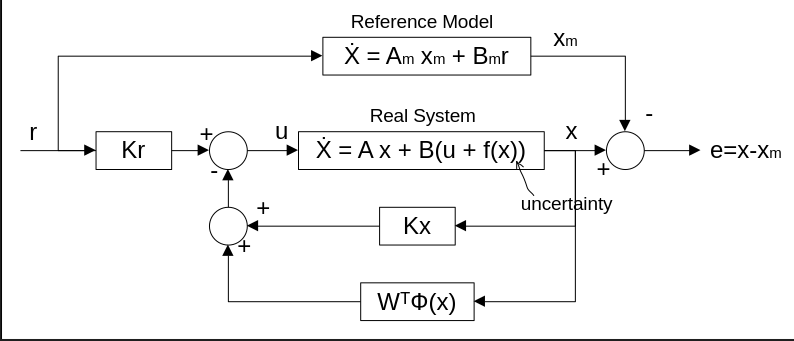

In [1]:
import numpy as np
import scipy, copy
import matplotlib.pyplot as plt
from cartpole_utils import Agent, test_cartpole, display_frames_as_gif, env_cartpole, HTML

## Simple Example

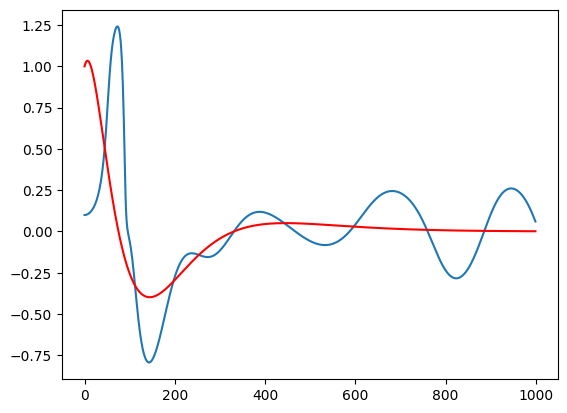

In [2]:
import scipy.linalg


xs, xms = [], []
# 1. System Parameters (Simplified Cartpole)
M, m, L, g = 1.0, 0.1, 0.5, 9.81
A = np.array([[0, 1, 0, 0],
              [0, 0, m*g/M, 0],
              [0, 0, 0, 1],
              [0, 0, (M+m)*g/(M*L), 0]])
B = np.array([[0], [1/M], [0], [1/(M*L)]])

# 2. Reference Model (How we WANT the cartpole to behave)
# We choose a stable Am (e.g., using LQR or pole placement)
Am = A - B @ np.array([[1.0, 2.0, 2.0, 1.5]]) # Example stable gains
poles = [-1.0, -2.5, -1.5, -1.1] # should be chosen to fit the physical feasibility of the system, otherwise the system will become unstable or fail
K_ref = scipy.signal.place_poles(A, B, poles).gain_matrix

Am = A - B @ K_ref
Bm = B.copy()

# 3. Lyapunov Setup
Q = np.eye(4) * 1
P = scipy.linalg.solve_continuous_lyapunov(Am.T, -Q)

# 4. Adaptive Gains & Hyperparameters
gamma_x = 1 # Learning rate for Kx, crucial for convergence or divergence
gamma_r = 1 # Learning rate for Kr
Kx = np.zeros((1, 4))
Kr = np.zeros((1, 1))

# Simulation Loop
x = np.array([[0.0, 0.0, 0.1, 0.0]]).T # Start slightly tilted (0.1 rad)
xm = np.zeros((4, 1)) + 1.0
dt = 0.01

for t in range(1000):
    r = 0.0 # Goal: stay at center, upright
    e = x - xm
    
    xs.append(x.copy())
    xms.append(xm.copy())
    
    # Control Law
    u = Kx @ x + Kr * r # clip values for real system

    # Adaptation Laws (Gradients)
    dKx = -gamma_x * (B.T @ P @ e) @ x.T
    dKr = -gamma_r * (B.T @ P @ e) * r
    
    # Update Gains
    Kx += dKx * dt # clip values for real system
    Kr += dKr * dt
    
    # System & Model Update (Euler)
    x_dot = A @ x + B @ u
    xm_dot = Am @ xm + Bm * r
    
    x += x_dot * dt
    xm += xm_dot * dt

plt.plot([x[2] for x in xs])
plt.plot([x[2] for x in xms], 'r')

## CartPole

In [3]:
class MRACControlAgent(Agent):
    def __init__(self, r, Q):
        """
        Initialize the MRAC controller.
        Args:
            env: The gym environment for the cart-pole.
            gamma: The adaptation gain.
        """
        super().__init__()
        self.state_dim = 4
        self.gamma_x = 0.05 # gain update rate
        self.gamma_r = 0.05
        self.dt = 0.01 # this is not really matter in our case

        self.states = []
        self.forces = []
        self.errors = []
        self.reference = []
        self.Ks = []

        self.Q = Q # Penalize theta error more
        self.r = r # targets
        
        # see LQR in CT01_Control_system
        self.A = np.array([[ 0., 1.,  0.         , 0.],
                           [ 0., 0., -0.71707317 , 0.],
                           [ 0., 0.,  0.         , 1.],
                           [ 0., 0., 15.77560976 , 0.]])
        self.B = np.array([[ 0.], [ 0.97560976], [ 0.], [-1.46341463]])
        
        # compute the reference model
        poles = [-1.5, -1.2, -1.4, -1.3] # should be chosen to fit the physical feasibility of the system, otherwise the system will become unstable or fail
        K_ref = scipy.signal.place_poles(self.A, self.B, poles).gain_matrix
        
        self.Am = self.A - self.B @ K_ref
        self.Bm = -self.Am

        # Initialize adaptive gains
        self.Kx = np.zeros((1, self.state_dim))
        self.Kr = np.linalg.pinv(self.B) @ self.Bm # using np.zeros((1, self.state_dim)) may fail the system

        # Solve the Lyapunov equation for the adaptation law - stable
        self.P = scipy.linalg.solve_continuous_lyapunov(self.Am.T, -self.Q)
        
        # initialize reference model
        self.xm = np.zeros((self.state_dim,))


    def act(self, state, train=True):
        """
        Calculate the control action.
        """
        self.u = self.Kx @ state + self.Kr @ self.r
        
        # update the gains
        self.update_parameters(state)
        
        action = 1 if self.u > 0 else 0 # expects a discrete action (0 or 1)
        
        self.forces.append(action)
        
        return action


    def update_parameters(self, state):
        """
        Update the adaptive gains.
        """
        # compute the reference model
        xm_dot = self.Am @ self.xm + (self.Bm @ self.r)
        self.xm += self.dt * xm_dot
        
        # Calculate the error using the state *after* the action
        error = state - self.xm

        # Adaptation law
        # B.T (1x4) @ P (4x4) @ e (4x1) -> Result is (1x1)
        epsilon = self.B.T @ self.P @ error

        # epsilon (1x1) @ state.reshape(1,4) -> Result is (1x4)
        dKx = -self.gamma_x * (epsilon @ state.reshape(1,4))
        dKr = -self.gamma_r * (epsilon @ self.r.reshape(1,4))

        # Update gains
        self.Kx += dKx * self.dt
        self.Kr += dKr * self.dt
        
        # save parameters
        self.states.append(state)
        self.reference.append(copy.copy(self.xm))
        self.Ks.append((self.Kx.copy(), self.Kr.copy()))
        self.errors.append(np.mean(error**2))

  
    def plot(self, interval=-1):
        fig1, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1)
        self.states = np.array(self.states).T
        self.reference = np.array(self.reference).T
        ax1.plot(self.states[0][:interval])
        ax1.plot(self.reference[0][:interval], 'r')
        ax1.set_title("Position")
        ax2.plot(self.states[1][:interval])
        ax2.plot(self.reference[1][:interval], 'r')
        ax2.set_title("Velocity")
        ax3.plot(self.states[2][:interval])
        ax3.plot(self.reference[2][:interval], 'r')
        ax3.set_title("Angle")
        ax4.plot(self.forces)
        ax4.set_title("Force")
        
        fig2, (ax1) = plt.subplots(1, 1)
        for i in range(4):
            ax1.plot([ks[0][:,i] for ks in self.Ks])
            ax1.plot([ks[1][:,i] for ks in self.Ks], '-')

In [4]:
Q = np.diag([10., 0.01, 100, 0.001])

r = np.array([-1.0, 0. ,0. , 0.]) 
mracagent = MRACControlAgent(r, Q)
frames = test_cartpole(env_cartpole, 500, agent=mracagent, train=True)
anim = display_frames_as_gif(frames)
HTML(anim.to_jshtml())

/home/niuniu/Documents/RL/env_rl/lib64/python3.13/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


501


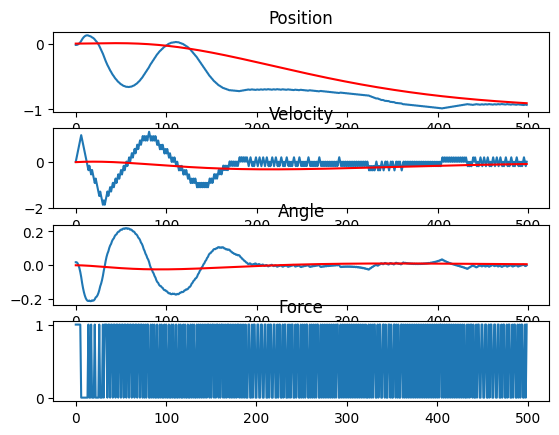

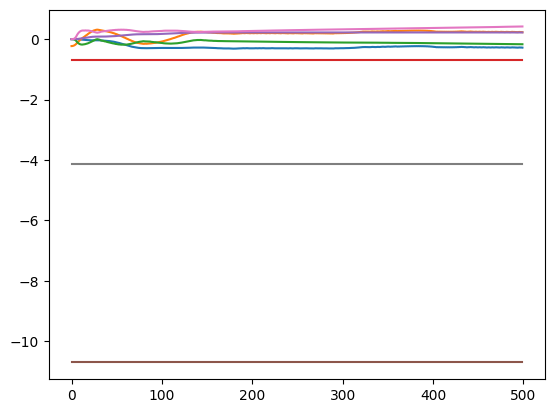

In [5]:
mracagent.plot()

## Add Noise Bloc

In [6]:
class MRACControlAgent2(Agent):
    def __init__(self, r, Q):
        """
        Initialize the MRAC controller.
        Args:
            env: The gym environment for the cart-pole.
            gamma: The adaptation gain.
        """
        super().__init__()
        self.state_dim = 4
        self.gamma_x = 0.05
        self.gamma_r = 0.05
        self.gamma_w = 0.005
        self.dt = 0.01 # this is not really matter in our case

        self.states = []
        self.forces = []
        self.errors = []
        self.reference = []
        self.Ks = []

        self.Q = Q # Penalize theta error more
        self.r = r # targets
        
        # see LQR in CT01_Control_system
        self.A = np.array([[ 0., 1.,  0.         , 0.],
                           [ 0., 0., -0.71707317 , 0.],
                           [ 0., 0.,  0.         , 1.],
                           [ 0., 0., 15.77560976 , 0.]])
        self.B = np.array([[ 0.], [ 0.97560976], [ 0.], [-1.46341463]])
        
        # compute the reference model
        poles = [-1.5, -1.2, -1.1, -1.3] # should be chosen to fit the physical feasibility of the system, otherwise the system will become unstable or fail
        K_ref = scipy.signal.place_poles(self.A, self.B, poles).gain_matrix
        
        self.Am = self.A - self.B @ K_ref
        self.Bm = -self.Am

        # Initialize adaptive gains
        self.Kx = np.zeros((1, self.state_dim))
        self.Kr = np.linalg.pinv(self.B) @ self.Bm # using np.zeros((1, self.state_dim)) may fail the system

        # Solve the Lyapunov equation for the adaptation law
        self.P = scipy.linalg.solve_continuous_lyapunov(self.Am.T, -self.Q)

        # RBF Network Initialization
        self.num_rbf_centers = 625
        self.rbf_width = 1.0
        # Create a grid of centers for pole angle and angular velocity
        pos_centers = np.linspace(-4.8, 4.8, 5)
        vel_centers = np.linspace(-4.0, 4.0, 5)
        angle_centers = np.linspace(-0.4, 0.4, 5)
        ang_vel_centers = np.linspace(-4.0, 4.0, 5)
        self.rbf_centers = np.array(np.meshgrid(pos_centers, vel_centers, angle_centers, ang_vel_centers)).T.reshape(-1, 4)
        self.W = np.zeros((1, self.num_rbf_centers))
        
        self.xm = np.zeros((self.state_dim,))


    def _rbf_layer(self, state):
        """
        Calculates the RBF feature vector.
        """
        rbf_state = state
        phi = np.exp(-np.linalg.norm(rbf_state - self.rbf_centers, axis=1)**2 / (2 * self.rbf_width**2))
        return phi.reshape(1, -1)


    def act(self, state, train=True):
        """
        Calculate the control action.
        """
        self.phi = self._rbf_layer(state)
        u_linear = self.Kx @ state + self.Kr @ self.r
        u_rbf = self.W @ self.phi.T

        self.u = u_linear - u_rbf
        
        action = 1 if self.u > 0 else 0 # expects a discrete action (0 or 1)
        
        self.update_parameters(state)
        
        self.forces.append(action)
        
        return action


    def update_parameters(self, state):
        """
        Update the adaptive gains.
        """
         # compute the reference model
        xm_dot = self.Am @ self.xm + (self.Bm @ self.r)
        self.xm += self.dt * xm_dot
        
        # Calculate the error using the state *after* the action
        error = state - self.xm
        
        # Adaptation law
        # B.T (1x4) @ P (4x4) @ e (4x1) -> Result is (1x1)
        epsilon = self.B.T @ self.P @ error

        # epsilon (1x1) @ state.reshape(1,4) -> Result is (1x4)
        dKx = -self.gamma_x * (epsilon @ state.reshape(1,4))
        dKr = -self.gamma_r * (epsilon @ self.r.reshape(1,4))
        dW = -self.gamma_w * (epsilon @ self.phi)
        
        # Update gains (using a small learning rate for stability)
        self.Kx += dKx * self.dt
        self.Kr += dKr * self.dt
        self.W += dW * self.dt

        # register some intermediate variables
        self.states.append(state)
        self.reference.append(copy.copy(self.xm))
        self.Ks.append((self.Kx.copy(), self.Kr.copy(), self.W.copy()))
        self.errors.append(np.mean(error**2))
        
             
    def plot(self, interval=-1):
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1)
        self.states = np.array(self.states).T
        self.reference = np.array(self.reference).T
        ax1.plot(self.states[0][:interval])
        ax1.plot(self.reference[0][:interval], 'r')
        ax1.set_title("Position")
        ax2.plot(self.states[1][:interval])
        ax2.plot(self.reference[1][:interval], 'r')
        ax2.set_title("Velocity")
        ax3.plot(self.states[2][:interval])
        ax3.plot(self.reference[2][:interval], 'r')
        ax3.set_title("Angle")
        ax4.plot(self.forces)
        ax4.set_title("Force")
        
        fig2, (ax1) = plt.subplots(1, 1)
        for i in range(4):
            ax1.plot([ks[0][:,i] for ks in self.Ks])
            ax1.plot([ks[1][:,i] for ks in self.Ks], '-')
            ax1.plot([ks[2][:,i] for ks in self.Ks], '+')

In [7]:
Q = np.diag([10., 0.01, 1000, 0.001])

r = np.array([-1.0, 0. ,0. , 0.]) 
mracagent2 = MRACControlAgent2(r, Q)
frames = test_cartpole(env_cartpole, 500, agent=mracagent2, train=True)
anim = display_frames_as_gif(frames)
HTML(anim.to_jshtml())

501


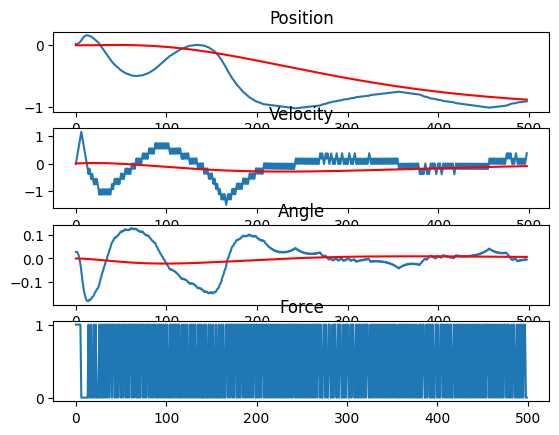

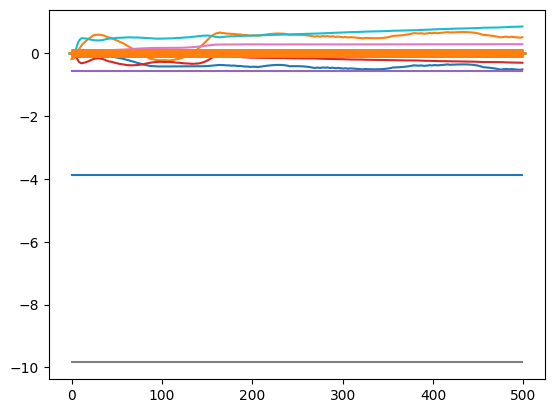

In [8]:
mracagent2.plot()